In [26]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2
pjoin = os.path.join

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
from src.plotting.visutil import CSVPlotter
from scripts.PrepABCD import df_base_dir, plt_base_dir, pjoin, ARUtil, prep_sign_rwgt, FakeUtil, train_mlp_rwgt
from hep_rewgt_tk.reweight_nn import SingleMLPRwgter
from scripts.PrepABCD import get_ABCD_results, prep_sign_rwgt, read_two_channels_df, get_mbb_train_test, train_and_reweight, load_and_plot, drop_kwds
from config.plotsetting import dR, H_pt, HT, infer_H_mass, train_H_mass, H_mass, tau_pt

## Pre-clean datasets

In [28]:
OS_0b = pd.read_csv(pjoin(df_base_dir, 'zerob', 'OS_vloose.csv'))
SS_0b = pd.read_csv(pjoin(df_base_dir, 'zerob', 'SS_vloose.csv'))

/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_4628/2005115203.py:1: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  OS_0b = pd.read_csv(pjoin(df_base_dir, 'zerob', 'OS_vloose.csv'))
/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_4628/2005115203.py:2: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  SS_0b = pd.read_csv(pjoin(df_base_dir, 'zerob', 'SS_vloose.csv'))


In [29]:
MC_df = FakeUtil.count_real_taus(OS_0b)
Data_df = OS_0b[OS_0b['group'] == 'Data']

Total number of events in data: 122191.0
Total number of MC TTbar events with real taus: 320.15273911791536
Total number of MC TTbar events with fake taus: 137.84439909719651
Total number of MC DYJets events with fake taus: 201.06728591587998
Total Number of MC events with real taus: 14583.081960405727


In [14]:
mlp_rwgter = SingleMLPRwgter(MC_df, Data_df, 'weight', f"{df_base_dir}/DataVSMC/trial", drop_kwd=drop_kwds)
mlp_rwgter.prep_data()

Dropped  807  events with negative weights out of  81069  events.
Dropped  0  events with negative weights out of  122191  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'nTau_values', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'LDBjet_nconstituents', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'SDBjet_nconstituents', 'nJets_values', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']


In [21]:
len(MC_df)

81069

In [15]:
checkpoint_path = f"{df_base_dir}/training/DataVSMC/trial_100.pth"
input_dim = len(mlp_rwgter.features)
mlp_rwgter.load_checkpoint(checkpoint_path, input_dim, 'high_dim')

Loaded model from epoch 99


/Users/yuntongzhou/Desktop/Dihiggszztt/HEPReWgtTK/hep_rewgt_tk/reweight_nn.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map

99

In [13]:
mlp_rwgter = train_mlp_rwgt(MC_df, Data_df, 'trial', 'DataVSMC')

Dropped  807  events with negative weights out of  81069  events.
Dropped  0  events with negative weights out of  122191  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'nTau_values', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'LDBjet_nconstituents', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'SDBjet_nconstituents', 'nJets_values', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']
Epoch 1/100, Train Loss: 0.3627, Val Loss: 0.3491
Epoch 11/100, Train Loss: 0.3293, Val Loss: 0.3248
Epoch 21/100, Tra

In [16]:
Data_sum = len(Data_df)
reweighted_MC = mlp_rwgter.reweight(MC_df, Data_sum)

Dropped  807  events with negative weights out of  81069  events.


In [17]:
rwgt_ratio = {
    "rwgt_ratio": {
        "hist": {'bins': 40, 'range': [0,100]},
        "plot": {'xlabel': r'rwgt ratio'}},
    }

In [44]:
reweighted_MC['weight'].sum()

122296.32522030076

In [43]:
Data_df['weight'].sum()

122191.0

In [38]:
reweighted_OS_0b = pd.concat([reweighted_MC, Data_df], ignore_index=True)

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:149: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:149: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),


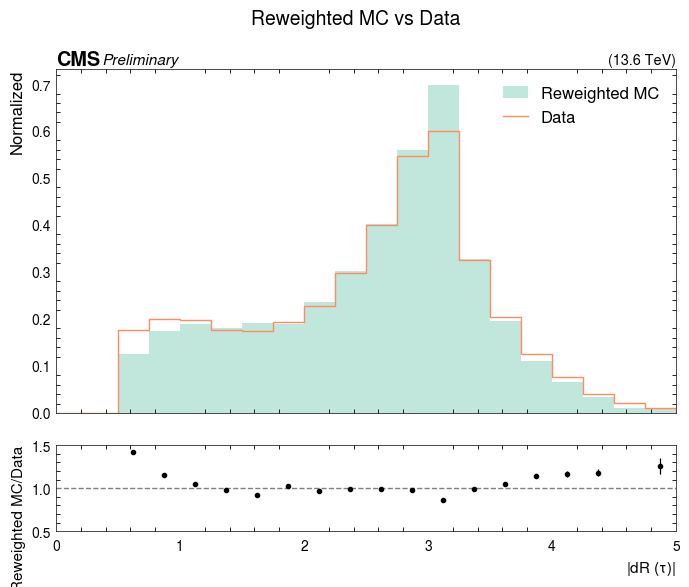

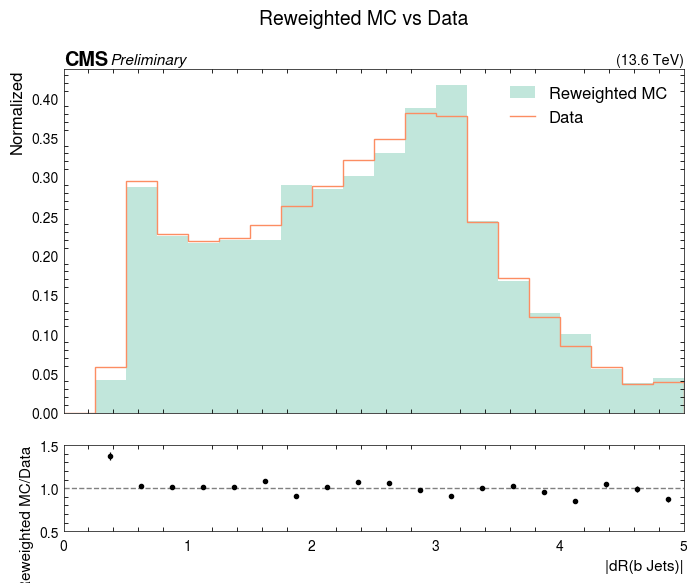

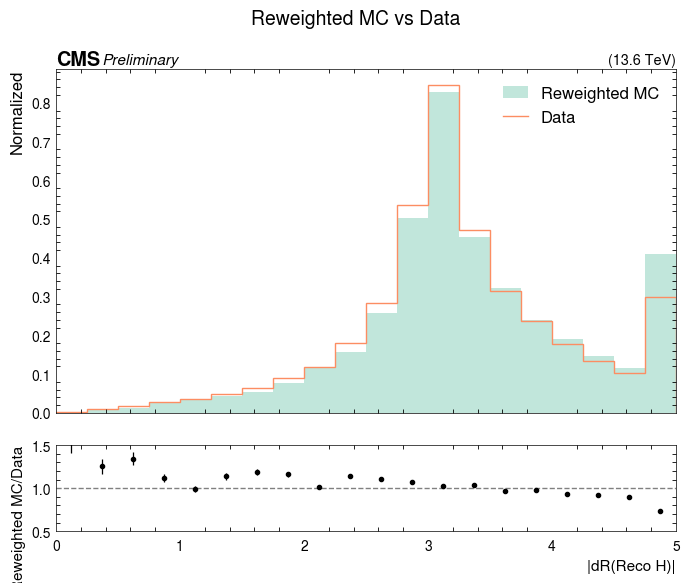

In [45]:
plotter = CSVPlotter(pjoin(plt_base_dir, 'zerob', 'rwgt_mlp'))
plotter.plot_shape([reweighted_OS_0b, Data_df], ['Reweighted MC', 'Data'], dR, 
                   'Reweighted MC/Data', pjoin(plt_base_dir, 'zerob', 'rwgt_mlp'), 
                   normalize=True, title='Reweighted MC vs Data', save_suffix='_rwgt_mc')

In [ ]:
ss_1b, val_ss_1b, os_1b, val_os_1b = get_mbb_train_test(Res1b_SS, Res1b_OS, mbb_cut=0)
ss_2b, val_ss_2b, os_2b, val_os_2b = get_mbb_train_test(Res2b_SS, Res2b_OS, mbb_cut=0)

# get_ABCD_results(val_os_1b, os_1b, val_ss_1b, ss_1b, 'res1b')
get_ABCD_results(val_os_2b, os_2b, val_ss_2b, ss_2b, 'res2b')